In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import chi2

df = pd.read_excel("Amsterdam-listings_m.xlsx")



In [3]:
df.head(5)

,id,listing_url,scrape_id,last_scraped,name,description,neighborhood_overview,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2818,https://www.airbnb.com/rooms/2818,20210409161549,2021-04-12,Quiet Garden View Room & Super Fast WiFi,Quiet Garden View Room & Super Fast WiFi<br />...,"Indische Buurt (""Indies Neighborhood"") is a ne...",https://a0.muscache.com/pictures/10272854/8dcc...,3159,https://www.airbnb.com/users/show/3159,...,10.0,9.0,10.0,NaN,t,1,0,1,0,1.90
1,20168,https://www.airbnb.com/rooms/20168,20210409161549,2021-04-12,Studio with private bathroom in the centre 1,17th century Dutch townhouse in the heart of t...,Located just in between famous central canals....,https://a0.muscache.com/pictures/69979628/fd6a...,59484,https://www.airbnb.com/users/show/59484,...,10.0,10.0,9.0,0363 CBB3 2C10 0C2A 1E29,t,2,0,2,0,2.50
2,25428,https://www.airbnb.com/rooms/25428,20210409161549,2021-04-11,"Lovely, 1 bed apt in Ctr (w.lift) -3/20-6/20(f...",Lovely apt in Centre ( lift & fireplace) near ...,NaN,https://a0.muscache.com/pictures/138431/7079a9...,56142,https://www.airbnb.com/users/show/56142,...,10.0,10.0,10.0,NaN,f,2,2,0,0,0.13
3,27886,https://www.airbnb.com/rooms/27886,20210409161549,2021-04-11,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,...,10.0,10.0,10.0,0363 974D 4986 7411 88D8,t,1,0,1,0,1.94
4,28871,https://www.airbnb.com/rooms/28871,20210409161549,2021-04-13,Comfortable double room,<b>The space</b><br />In a monumental house ri...,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,...,10.0,10.0,10.0,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,2.59


In [2]:


df = df.dropna(subset=["review_scores_rating"])

interval=pd.interval_range(start=20, end= 104, freq=6, closed="left")


analisis =( pd.cut(df["review_scores_rating"],bins=interval)
            .value_counts()
            .sort_index()
            .reset_index()
            .rename(columns={"review_scores_rating":"Intervalo",
                             "count": "Frecuencia" }))

analisis["Frecuencia relativa"] = analisis["Frecuencia"].apply(lambda x: x/analisis["Frecuencia"].sum())

analisis["Porcentaje Frec Rel"]= analisis["Frecuencia relativa"]*100
analisis["Frecuencia Ac"] = analisis["Frecuencia"].cumsum()
analisis["Porcentaje Frec Ac"] = analisis["Porcentaje Frec Rel"].cumsum()




In [ ]:
p53= np.percentile(df["review_scores_rating"],53,method="weibull")
mini = df["review_scores_rating"].min()
print(p53)
print(mini)


In [ ]:
#Ej 2


precios = pd.to_numeric(df["price"], errors="coerce")

precios=( precios[(precios.notna())&(precios != 0)]
         .sort_values()
         .reset_index(drop=True))

p78 = np.percentile(precios,78,method="weibull")

precios_fil = precios[precios>p78]

media=precios_fil.mean()





print(media)
print(p78)

In [ ]:
#Ej 3

media = precios.mean()
debajo = precios[precios<media]
prop = debajo.count()/precios.count()

print(prop)
print(media)

In [ ]:
#Ej 4
desv =precios.std() + media
inm = media + 100

veces = inm/desv

print(veces) 
print(inm)
print(desv)

In [ ]:
room = df["room_type"].value_counts().reset_index()
room.columns=["Habitaciones","Conteo"]
fig = px.bar(room,x="Habitaciones",y="Conteo")
fig.show()
room.head(5)


In [ ]:
df = (
    df.assign(price= pd.to_numeric(df["price"],errors="coerce"))
    .query("price>0")
    .reset_index(drop=True)
)

df["group"]=pd.cut(
            df["price"],
            bins=[df["price"].min(),130,df["price"].max()],
            labels=["<130",">= 130"],
            right=False)


gr = df.groupby(["room_type","group"]).count().reset_index()[["id","room_type","group"]]
gr=gr.rename(columns={"id":"conteo","room_type":"habitacion","group":"precio"})



fig = px.bar(gr,x="habitacion",y="conteo",color="precio",barmode="group")




fig.show()
gr.head(5)






In [ ]:


df = (
    df.assign(price= pd.to_numeric(df["price"],errors="coerce"))
    .query("price>0")
    .reset_index(drop=True)
)
df=df.rename(columns={"price":"precio","room_type":"habitacion"})



fig= px.box(df,x="precio",y="habitacion",color="habitacion")
fig.show()



In [ ]:
df["review"]=pd.cut(
                    df["review_scores_rating"],
                    bins=[df["review_scores_rating"].min(),88,df["review_scores_rating"].max()],
                    right=False,
                    labels=["<88",">=88"]
)


fig = px.box(df,x="precio",y="habitacion", color="review")
fig.show()


In [ ]:
#Exploracion del dataset

df.head()
df[["review_scores_communication", "review_scores_rating", "room_type"]].dtypes
df.shape
df.isna().sum()/len(df) #cuenta para cada columa el porcentaje faltante
df.shape




In [ ]:
df.dropna
df.shape


In [ ]:
df.duplicated()
df.drop_duplicates()
df.duplicated().sum()

In [33]:
#Ejercicios de correlacion

df = df.query("review_scores_communication > 0 and review_scores_rating>0")

df[["review_scores_communication","review_scores_rating"]].isna().sum()
(df[["review_scores_communication","review_scores_rating"]]==0).sum()



review_scores_communication    0
review_scores_rating           0
dtype: int64

,review_scores_communication,review_scores_rating
review_scores_communication,1.000000,0.658239
review_scores_rating,0.658239,1.000000


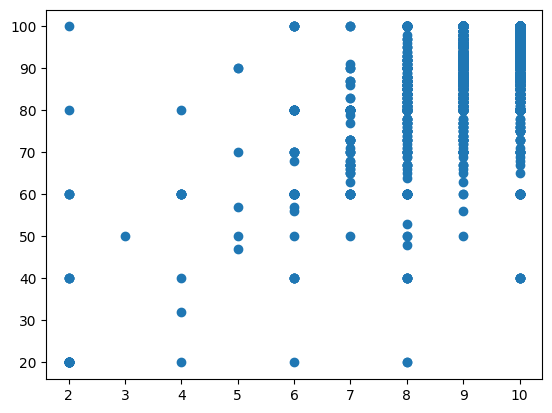

In [41]:
plt.scatter(df["review_scores_communication"],df["review_scores_rating"])
fig = px.scatter(df, y="review_scores_communication", x="review_scores_rating",color="room_type",trendline="ols")

fig.show()

df[["review_scores_communication","review_scores_rating"]].corr(method="pearson")

In [12]:

df["score"]= pd.cut(
                        df["price"],
                        bins=range(20,101,10),
                        right= False
                        )


#tabla_contingencia=pd.crosstab(df["score"],df["room_type"],margins=True,normalize="columns")

#tabla_contingencia=pd.crosstab(df["score"],df["room_type"],margins=True,normalize="all")

tabla_contingencia=pd.crosstab(df["score"],df["room_type"],margins=True,normalize="index")

tabla=pd.crosstab(df["score"],df["room_type"],margins=True)
tabla_contingencia = tabla_contingencia*100
tabla_contingencia
tabla

room_type,Entire home/apt,Hotel room,Private room,Shared room,All
score,,,,,
"[20, 30)",3,4,70,5,82
"[30, 40)",12,7,118,3,140
"[40, 50)",41,5,202,5,253
"[50, 60)",97,4,295,2,398
"[60, 70)",171,2,379,8,560
"[70, 80)",369,9,415,3,796
"[80, 90)",546,11,349,4,910
"[90, 100)",873,6,291,0,1170
All,2112,48,2119,30,4309


In [13]:
chi, pval, dof, exp = chi2_contingency(tabla_contingencia)
print("El valor p es:", pval)
significancia=0.05

p = 1-significancia
valor_crit=chi2.ppf(p,dof)
print("chi=%.6f, valor critico=%f\n" % (chi,valor_crit))


if chi> valor_crit:
    print(" Se rechaza la hipótesis nula de que son independientes")
else:
    print(" No se rechaza la hipótesis nula")


El valor p es: 6.017740875103436e-35
chi=226.876558, valor critico=36.415029

 Se rechaza la hipótesis nula de que son independientes


In [ ]:
 df["host_neighbourhood"].isin(["Centrum-Oost", "Centrum-West"]),["host_neighbourhood", "dat = df.loc[price"]
]

dat.head(5)

if "Centrum-Oost" in df["host_neighbourhood"]:
    print("True")